# CELL 1: Install Dependencies & Setup

### First, we need to bring in the tools. The paper uses the SwinIR architecture. Instead of coding that massive math formula from scratch, we will download the official code repository.

In [1]:
# CELL 1: RUN THIS FIRST
!git clone https://github.com/JingyunLiang/SwinIR.git
import sys
sys.path.append('/kaggle/working/SwinIR')

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Ensure Kaggle uses the GPU!
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}")

Cloning into 'SwinIR'...
remote: Enumerating objects: 333, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 333 (delta 6), reused 2 (delta 2), pack-reused 323 (from 2)
Receiving objects: 100% (333/333), 29.84 MiB | 6.73 MiB/s, done.
Resolving deltas: 100% (119/119), done.
🚀 Using device: cuda


In [2]:
!pip install rasterio

# CELL 2: Data Processing

This code pairs each high-resolution RGB image with a low-resolution satellite .tiff file and converts that scientific data into a normal image. The .tiff isn’t a regular picture—it contains multiple bands, where each band is a grayscale image capturing a specific wavelength of light (like red, green, blue, infrared). In the lines src.read(4), src.read(3), src.read(2), the code is selecting the Red, Green, and Blue bands from that multi-band data. These values are scaled from scientific reflectance (0–10000) into standard image pixel values (0–255), stacked into a color image, and saved so the model can learn to map low-resolution inputs to high-resolution outputs.

In [3]:
import os
import rasterio
import numpy as np
import cv2
import shutil
from tqdm import tqdm

# 1. PATH CONFIGURATION
raw_dir = "/kaggle/input/datasets/jucor1/worldstrat/"
hr_base = os.path.join(raw_dir, "hr_dataset", "12bit")
lr_base = os.path.join(raw_dir, "lr_dataset")

clean_lr_dir = "/kaggle/working/cleaned_dataset/lr_dir"
clean_hr_dir = "/kaggle/working/cleaned_dataset/hr_dir"

os.makedirs(clean_lr_dir, exist_ok=True)
os.makedirs(clean_hr_dir, exist_ok=True)

def verify_image(filepath):
    """Checks if the image file is actually readable and not empty."""
    img = cv2.imread(filepath)
    if img is None or img.size == 0:
        return False
    return True

def process_lr_tiff(tiff_path, output_filepath):
    try:
        with rasterio.open(tiff_path) as src:
            # Sentinel-2 Band Order: 4=Red, 3=Green, 2=Blue
            red = src.read(4).astype(np.float32)
            green = src.read(3).astype(np.float32)
            blue = src.read(2).astype(np.float32)
            
        gain = 1.5 
        red = np.clip(red * 255.0 * gain, 0, 255)
        green = np.clip(green * 255.0 * gain, 0, 255)
        blue = np.clip(blue * 255.0 * gain, 0, 255)
        
        bgr_image = np.dstack((blue, green, red)).astype(np.uint8)
        
        # Save and then immediately verify it wrote correctly
        cv2.imwrite(output_filepath, bgr_image)
        return verify_image(output_filepath)
    except Exception:
        return False

# 3. EXECUTION LOOP
locations = [d for d in os.listdir(hr_base) if os.path.isdir(os.path.join(hr_base, d))]

print(f"🔄 Processing and Validating {len(locations)} locations...")

valid_count = 0
for loc in tqdm(locations):
    hr_image_path = os.path.join(hr_base, loc, f"{loc}_rgb.png")
    lr_tiff_path = os.path.join(lr_base, loc, "L2A", f"{loc}-1-L2A_data.tiff")
    
    if os.path.exists(hr_image_path) and os.path.exists(lr_tiff_path):
        out_hr = os.path.join(clean_hr_dir, f"{loc}.png")
        out_lr = os.path.join(clean_lr_dir, f"{loc}.png")
        
        # Check source HR before copying
        if not verify_image(hr_image_path):
            continue # Skip this location entirely if HR is broken
            
        # Copy HR and Process LR
        shutil.copy(hr_image_path, out_hr)
        success_lr = process_lr_tiff(lr_tiff_path, out_lr)
        
        # FINAL SANITY CHECK: If LR failed, delete the HR copy to prevent orphans
        if not success_lr:
            if os.path.exists(out_hr): os.remove(out_hr)
            if os.path.exists(out_lr): os.remove(out_lr)
        else:
            valid_count += 1

print(f"✅ Finished! Generated {valid_count} healthy image pairs.")

🔄 Processing and Validating 3929 locations...


100%|██████████| 3929/3929 [07:29<00:00,  8.75it/s]

✅ Finished! Generated 3927 healthy image pairs.


# CELL - 3: Data Validation & Visualization

Before training, it's crucial to verify the image pairs. Here, we randomly sample and visualize the Low-Resolution (LR) and High-Resolution (HR) ground truth pairs to ensure they are correctly aligned and processed.

Total matched pairs: 3927


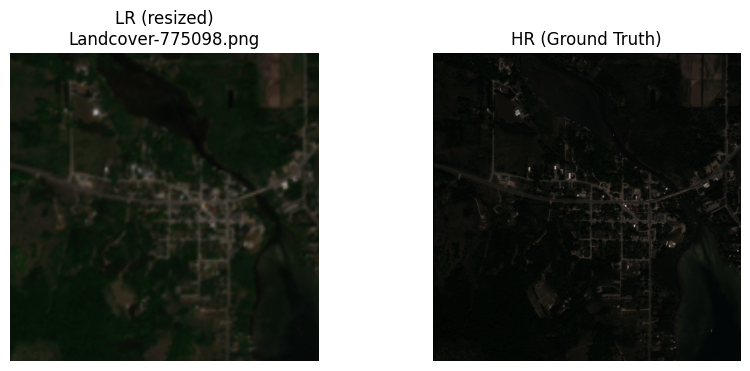

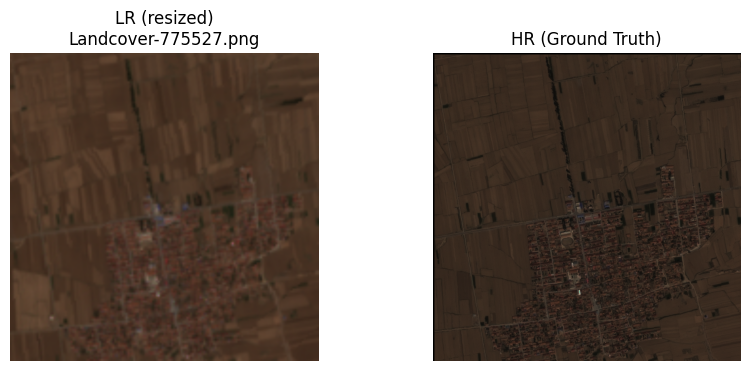

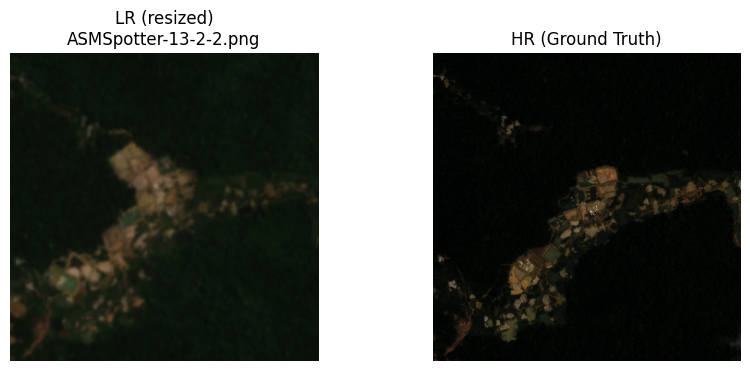

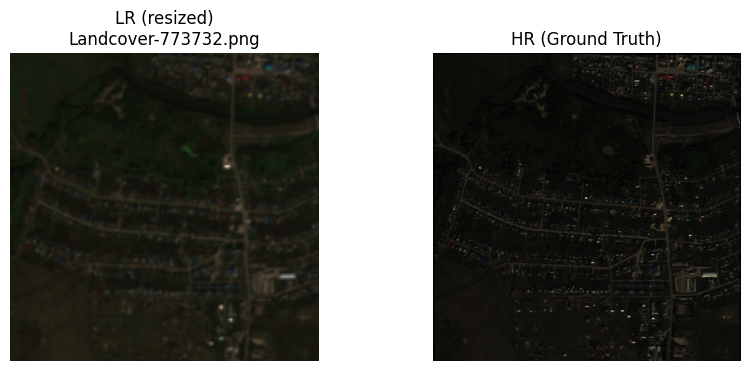

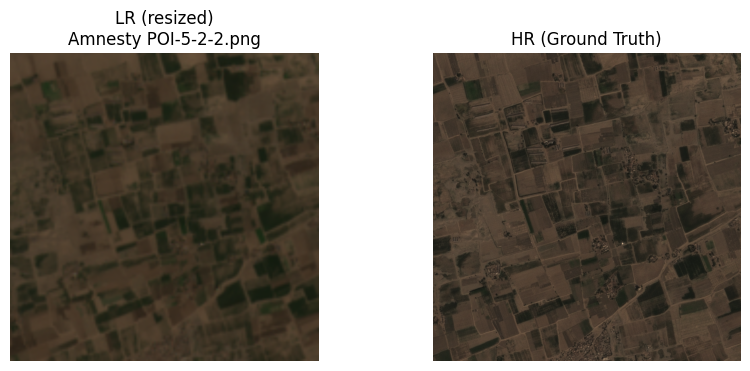

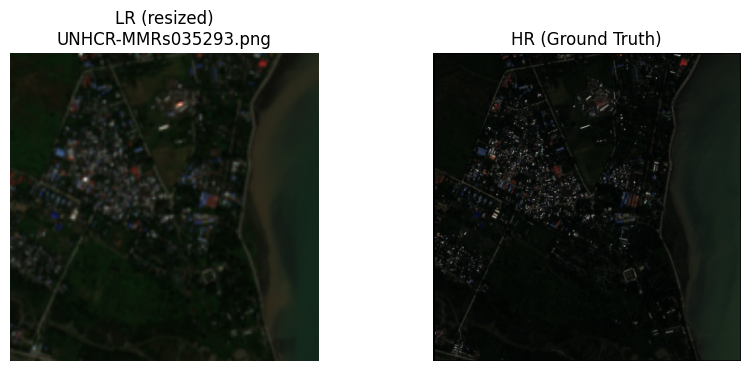

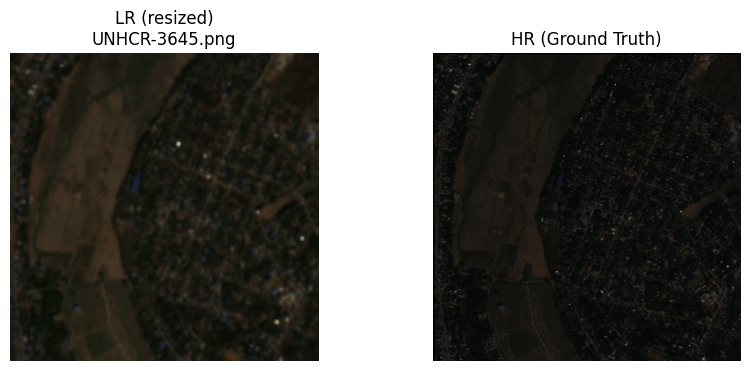

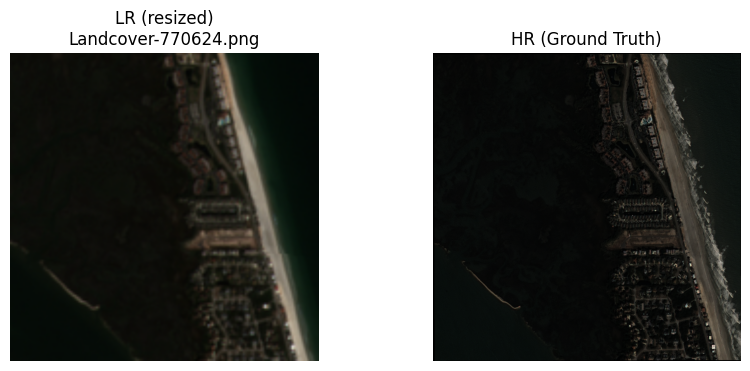

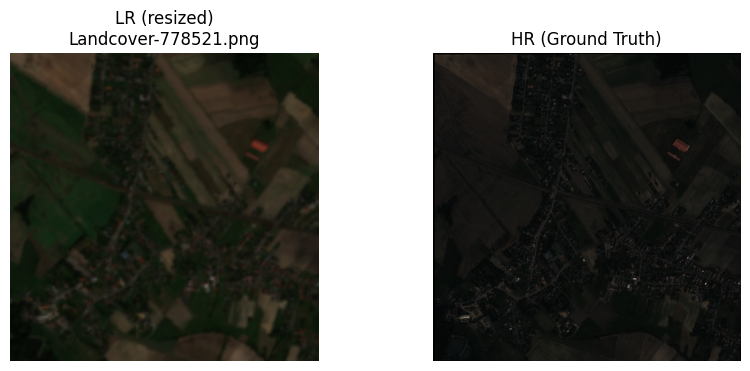

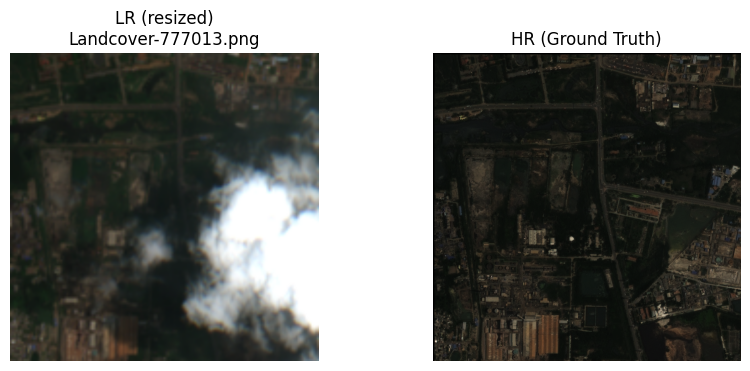

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

lr_dir = "/kaggle/working/cleaned_dataset/lr_dir"
hr_dir = "/kaggle/working/cleaned_dataset/hr_dir"

# Get common filenames (safety check)
lr_files = set(os.listdir(lr_dir))
hr_files = set(os.listdir(hr_dir))

common_files = list(lr_files.intersection(hr_files))

print("Total matched pairs:", len(common_files))

# Pick 10 random samples
samples = random.sample(common_files, min(10, len(common_files))) # random.sample(sequence, k): It selects k unique elements from a sequence. A key rule is that k cannot be larger than the total number of items in the list; if it is, Python throws a ValueError. That is why i used min

for file in samples:
    lr_path = os.path.join(lr_dir, file)
    hr_path = os.path.join(hr_dir, file)

    # Load images
    lr_img = cv2.imread(lr_path)
    hr_img = cv2.imread(hr_path)

    # Convert BGR → RGB for correct display
    lr_img = cv2.cvtColor(lr_img, cv2.COLOR_BGR2RGB)
    hr_img = cv2.cvtColor(hr_img, cv2.COLOR_BGR2RGB)

    # Resize LR to match HR size (for visual comparison)
    lr_resized = cv2.resize(lr_img, (hr_img.shape[1], hr_img.shape[0]))

    # Plot side by side
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(lr_resized)
    plt.title(f"LR (resized)\n{file}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(hr_img)
    plt.title("HR (Ground Truth)")
    plt.axis("off")

    plt.show()

# CELL - 4: PyTorch Dataset & DataLoader
PyTorch (the AI framework) needs data in a very specific format. A Dataset class is like a smart file organizer that knows:
1) How many items do I have? (__len__)
2) How do I get item number N? (__getitem__)

This code will read the images from your hard drive, convert them into mathematical tensors (matrix formats that the GPU can understand), and group them into "batches" so your SwinIR model can process multiple images at once during training.

We define a custom `WorldStratDataset` class to handle the data pipeline. This class performs on-the-fly resizing (LR to 128x128, HR to 512x512) and normalization, ensuring the model receives batches of tensors ready for training.


In [ ]:
import random

class WorldStratDataset(Dataset):
    def __init__(self, lr_dir, hr_dir, lr_size=128, hr_size=512):
        self.lr_dir = lr_dir
        self.hr_dir = hr_dir
        self.lr_size = lr_size 
        self.hr_size = hr_size
        
        valid_filenames = []
        for f in os.listdir(lr_dir):
            if f.endswith('.png'):
                if os.path.exists(os.path.join(hr_dir, f)):
                    valid_filenames.append(f)
                    
        self.image_filenames = valid_filenames
        print(f"📦 Dataset initialized with {len(self.image_filenames)} potential pairs.")
        
    def __len__(self):
        return len(self.image_filenames)
        
    def __getitem__(self, idx):
        try:
            img_name = self.image_filenames[idx]
            lr_path = os.path.join(self.lr_dir, img_name)
            hr_path = os.path.join(self.hr_dir, img_name)
            
            lr_img = cv2.imread(lr_path)
            hr_img = cv2.imread(hr_path)
            
            # If OpenCV fails to read (corrupted file), try a random different index
            if lr_img is None or hr_img is None:
                print(f"⚠️ Skipping corrupted file: {img_name}")
                return self.__getitem__(random.randint(0, len(self.image_filenames) - 1))
            
            # Standard processing
            lr_img = cv2.resize(lr_img, (self.lr_size, self.lr_size), interpolation=cv2.INTER_AREA)
            hr_img = cv2.resize(hr_img, (self.hr_size, self.hr_size), interpolation=cv2.INTER_CUBIC)
            
            lr_img = cv2.cvtColor(lr_img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
            hr_img = cv2.cvtColor(hr_img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
            
            return torch.from_numpy(lr_img).permute(2, 0, 1), torch.from_numpy(hr_img).permute(2, 0, 1) # permute(2, 0, 1) is used because when converting numpy array to pytorch tensor we should know that NumPy/OpenCV format: (Height, Width, Channels) — e.g., (512, 512, 3) while PyTorch format: (Channels, Height, Width) — e.g., (3, 512, 512).
            
        except Exception as e:
            # If any other error occurs (like libpng read error), grab a different image
            return self.__getitem__(random.randint(0, len(self.image_filenames) - 1))

# Setup dataloader (Batch size 2 to prevent Out Of Memory)
dataset = WorldStratDataset("/kaggle/working/cleaned_dataset/lr_dir", "/kaggle/working/cleaned_dataset/hr_dir", lr_size=128, hr_size=512)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, num_workers=2)

📦 Dataset initialized with 3927 potential pairs.


In [6]:
!pip install timm

# CELL - 5: SwinIR Model Configuration

1) It first adds the SwinIR repo path so Python can import your custom model instead of failing with a module error.
2) Then it selects GPU (CUDA) if available, otherwise CPU, and moves the model there for computation.
3) The SwinIR model is initialized with specific architecture settings (scale ×4, transformer depth, attention heads, etc.).
4) nn.L1Loss() defines how error is measured — it compares predicted super-res image vs real high-res image.
5) Adam optimizer defines how the model learns, updating weights using gradients with learning rate 0.0002.
6) StepLR scheduler automatically reduces the learning rate every 10 epochs, helping the model shift from fast learning → fine-tuning.

In [ ]:
import sys
import torch
import torch.nn as nn
import torch.optim as optim

if '/kaggle/working/SwinIR' not in sys.path:
    sys.path.append('/kaggle/working/SwinIR')

from models.network_swinir import SwinIR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using device: {device}")

model = SwinIR(
    upscale=4, # Telling the model to increase the resolution by a factor of 4 (e.g., 128 -> 512).
    in_chans=3, # The number of input color channels. Since we converted our satellite data to RGB, we have 3 channels (Red, Green, Blue).
    img_size=128, # expected width/height of the input tiles. It helps the model calculate how many "patches" it will need to process.
    window_size=8, # SwinIR is a "Shifted Window" Transformer. Instead of looking at the whole $128 \times 128$ image at once (which would crash the GPU), it breaks the image into $8 \times 8$ pixel windows. It calculates "Attention" inside these windows, then shifts the windows to see how they connect to their neighbors.
    img_range=1., # This matches our normalization. Since we divided by 255 to get a range of [0, 1], we tell the model to expect a maximum value of 1.0.
    embed_dim=60, # This is the "width" of the network. Each pixel is turned into a vector of 60 numbers to represent its features. It is called embedded vector 
    depths=[6, 6, 6, 6], # This means model has 4 main stages, and each stage has 6 Transformer layers. More layers = more intelligence, but slower training.
    num_heads=[6, 6, 6, 6], # This refers to Multi-Head Self-Attention. Example: Imagine 6 different experts looking at the same 8x8 window. One expert looks for edges, one looks for color gradients, one looks for shadows, etc. They then combine their notes.
    resi_connection='1conv', # It adds a 1x1 Convolutional layer to the shortcut path. It helps the "original" image information flow through the network without getting distorted by the complex Transformer math.
    mlp_ratio=2, # Inside each Transformer layer, there is a "Multi-Layer Perceptron" (a small mini-network). This ratio determines how much the data "expands" internally. With a ratio of 2, the 60 features are expanded to 120 during calculation and then squeezed back to $60$.
    upsampler='pixelshuffle' # A very efficient way to turn a "deep" small image into a "thin" large image by rearranging pixels.
).to(device)

criterion = nn.L1Loss() # L1 Loss (MAE): This calculates the absolute difference between the AI's output and the Ground Truth.
optimizer = optim.Adam(model.parameters(), lr=2e-4)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


🚀 Using device: cuda


# CELL - 6: 

In [ ]:
import os
import gc
import torch
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm

# -----------------------------
# 1) SETUP
# -----------------------------
torch.cuda.empty_cache()
gc.collect()

torch.backends.cudnn.benchmark = True  # Since our images are always exactly the same size (128x128 for LR, 512x512 for HR), this tells the NVIDIA graphics card to spend a few seconds before training to figure out the fastest possible mathematical route for this exact shape. It’s like a racecar driver doing a practice lap to find the best racing line.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

batch_size = 2
num_workers = 2

dataloader = DataLoader(
    dataset,
    batch_size=batch_size, # Single image: (3, 256, 256), Batch of 16 (batch dimension new) : (16, 3, 256, 256)
    shuffle=True,
    num_workers=num_workers, # Number of parallel subprocesses used for loading/preprocessing data. Workers load images while GPU is training on previous batch.
    pin_memory=(device.type == "cuda"), # Normally, data moves from the Hard Drive -> CPU RAM -> GPU VRAM. pin_memory creates a dedicated "Fast Lane" directly into the GPU, speeding up data transfer immensely.
    persistent_workers=(num_workers > 0) # Keeps worker processes alive between epochs. Without this after very epoch: create workers -> load data -> destroy workers. Creating subprocesses repeatedly is expensive for each epoch. With persistent_workers=True: Workers stay alive and get reused across epochs
)

# -----------------------------
# 2) SAVE PATHS
# -----------------------------
save_dir = "/kaggle/working/model_saves"
os.makedirs(save_dir, exist_ok=True)

latest_model_path = os.path.join(save_dir, "model_latest.pth")
best_model_path = os.path.join(save_dir, "model_best.pth")

# -----------------------------
# 3) TRAINING
# -----------------------------
num_epochs = 50
best_loss = float("inf")

print(f"Starting training for {num_epochs} epochs...")

# Automatic Mixed Precision (AMP): Normally, neural networks use 32-bit decimals (FP32) for extreme precision. However, a lot of the math doesn't need 32 bits; 16 bits (FP16) is fine.
use_amp = (device.type == "cuda") # autocast: This acts like a smart manager. It looks at the math equation and says, "We can do this part in 16-bit to save 50% of our memory and run twice as fast, but we'll do this sensitive part in 32-bit so we don't lose accuracy."
scaler = torch.cuda.amp.GradScaler(enabled=use_amp) #  When you use 16-bit math, the numbers can get so tiny that the computer rounds them to $0.00$ (Vanishing Gradients). The scaler multiplies the loss by a large number, does the math, and then scales it back down, protecting the tiny details from being erased.

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0

    pbar = tqdm(dataloader, desc=f"Epoch {epoch}/{num_epochs}")

    for lr_imgs, hr_imgs in pbar:
        lr_imgs = lr_imgs.to(device, non_blocking=True) # It tells the computer, "Start moving these images to the GPU right now, but don't freeze the rest of the code while you do it." It allows data transfer and mathematical calculations to overlap, saving precious seconds.
        hr_imgs = hr_imgs.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True) # Before a new image is processed, you must erase the "mistakes" (gradients) calculated from the previous image. set_to_none=True literally deletes them from memory rather than just changing the numbers to zero. It saves VRAM and time.
 
        with torch.cuda.amp.autocast(enabled=use_amp): # This is your Automatic Mixed Precision (AMP). It temporarily switches the GPU's math from 32-bit (heavy and slow) to 16-bit (light and fast) for calculations that don't need extreme decimal precision.
            outputs = model(lr_imgs) # The Forward Pass: The AI tries its best to upscale the image.
            loss = criterion(outputs, hr_imgs) # Compute Loss: The AI compares its guess to the Ground Truth (hr_imgs) using L1 Loss.

        scaler.scale(loss).backward() # The Backward Pass: The AI calculates exactly how wrong it was and figures out which weights to change to do better next time.
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = running_loss / len(dataloader)
    print(f"Epoch {epoch} done | Avg Loss: {avg_loss:.6f}")

    # Save latest model weights only
    torch.save(model.state_dict(), latest_model_path)

    # Save best model weights only
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model updated at epoch {epoch} | Loss: {best_loss:.6f}")

print("Training finished.")
print(f"Latest model saved at: {latest_model_path}")
print(f"Best model saved at:   {best_model_path}")

/tmp/ipykernel_22/1643787363.py:49: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Starting training for 50 epochs...


Epoch 1/50:   0%|          | 0/1964 [00:00<?, ?it/s]/tmp/ipykernel_22/1643787363.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 1/50: 100%|██████████| 1964/1964 [09:31<00:00,  3.44it/s, loss=0.0814]


Epoch 1 done | Avg Loss: 0.096430
Best model updated at epoch 1 | Loss: 0.096430


Epoch 2/50: 100%|██████████| 1964/1964 [09:24<00:00,  3.48it/s, loss=0.0557]


...

Epoch 48 done | Avg Loss: 0.064445
Best model updated at epoch 48 | Loss: 0.064445


Epoch 49/50: 100%|██████████| 1964/1964 [09:27<00:00,  3.46it/s, loss=0.0373]


Epoch 49 done | Avg Loss: 0.064468


Epoch 50/50: 100%|██████████| 1964/1964 [09:27<00:00,  3.46it/s, loss=0.0395]


Epoch 50 done | Avg Loss: 0.064628
Training finished.
Latest model saved at: /kaggle/working/model_saves/model_latest.pth
Best model saved at:   /kaggle/working/model_saves/model_best.pth
